In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.globaldefs as gd
import magnus.plotting as plotting

# 0. Helper functions and definitions

In [2]:
def flavor_index_to_str(nu_l):
    return {gd.NUE: 'e', gd.NUMU: 'mu', gd.NUTAU: 'tau'}[nu_l]


def eps_annotations(N):
    """The epsilon values a figure was made with, as annotation entries.

    Recording them on the figure matters more than usual here: an NSI plot is
    meaningless without the couplings that produced it, and these notebooks get
    read as images long after the code that made them.
    """
    if N == 2:
        return [dict(text=r'$\epsilon_{e e} =$ ' + str(eps_ee) + ', ' +
                          r'$\epsilon_{e \mu} =$ ' + str(eps_em) + ', ' +
                          r'$\epsilon_{\mu \mu} =$ ' + str(eps_mm),
                     xy=(0.02, 0.03), fontsize=18)]
    return [dict(text=r'$\epsilon_{e e} =$ ' + str(eps_ee) + ', ' +
                      r'$\epsilon_{e \mu} =$ ' + str(eps_em) + ', ' +
                      r'$\epsilon_{e \tau} =$ ' + str(eps_et),
                 xy=(0.02, 0.08), fontsize=18),
            dict(text=r'$\epsilon_{\mu \mu} =$ ' + str(eps_mm) + ', ' +
                      r'$\epsilon_{\mu \tau} =$ ' + str(eps_mt) + ', ' +
                      r'$\epsilon_{\tau \tau} =$ ' + str(eps_tt),
                 xy=(0.02, 0.03), fontsize=18)]


def _curves(prob_matt_nsi_all, prob_matt_std_all, nu_i, nu_f):
    return [dict(y=prob_matt_nsi_all[:, nu_i, nu_f], color='C1',
                 label=r'Matter effects with NSI'),
            dict(y=prob_matt_std_all[:, nu_i, nu_f], color='0.2', ls='--',
                 label=r'Standard matter effects')]


def make_plot_prob_matt_std_vs_nsi_vs_baseline(nu_i, nu_f, distances, prob_matt_nsi_all,
                                               prob_matt_std_all, N=3, title=None,
                                               save_plot=True):
    """NSI against standard matter effects, as a function of baseline."""
    filename = ('prob_matt_std_vs_nsi_' + str(N) + 'nu_vs_baseline_'
                + flavor_index_to_str(nu_i) + '_' + flavor_index_to_str(nu_f))
    return plotting.plot_probability_vs_baseline(
        distances, _curves(prob_matt_nsi_all, prob_matt_std_all, nu_i, nu_f),
        nu_i=nu_i, nu_f=nu_f, xlim=(l_ini, l_fin),
        annotations=eps_annotations(N),
        legend_loc='center left', title=title, title_fontsize=23,
        savefig=('../fig/' + filename + '.pdf') if save_plot else None,
        savefig_kw=dict(dpi=300))


def make_plot_prob_matt_std_vs_nsi_vs_energy(nu_i, nu_f, distances, prob_matt_nsi_all,
                                             prob_matt_std_all, N=3, title=None,
                                             save_plot=True):
    """The same comparison against neutrino energy."""
    filename = ('prob_matt_std_vs_nsi_' + str(N) + 'nu_vs_energy_'
                + flavor_index_to_str(nu_i) + '_' + flavor_index_to_str(nu_f))
    return plotting.plot_probability_vs_energy(
        energies, _curves(prob_matt_nsi_all, prob_matt_std_all, nu_i, nu_f),
        nu_i=nu_i, nu_f=nu_f, xlim=(energy_min, energy_max),
        annotations=eps_annotations(N),
        legend_loc='center right', title=title, title_fontsize=23,
        savefig=('../fig/' + filename + '.pdf') if save_plot else None,
        savefig_kw=dict(dpi=300))

# 1. Probabilities with NSI in 2$\nu$: in matter with constant density

## 1.1 Mixing parameters and NSI parameters

In [3]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

# NSI parameters (predefined exaples from globaldefs; can change them to anything else)
eps_ee, eps_em, eps_mm = gd.EPS_2

## 1.1 Probabilities vs. distance

Generate probabilities

In [4]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 2nu case, osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian
H_vac = hamiltonians.hamiltonian_2nu_vacuum(energy, s12, D21)

# Standard matter Hamiltonian
H_matt = hamiltonians.hamiltonian_2nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians.hamiltonian_2nu_nsi(VCC, eps_ee - eps_mm, eps_em)

# Probabilities
prob_matt_std_all = np.array([oscprob.osc_prob(lambda r: H_vac+H_matt, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda r: H_vac+H_matt+H_nsi, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])


Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '$2\\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

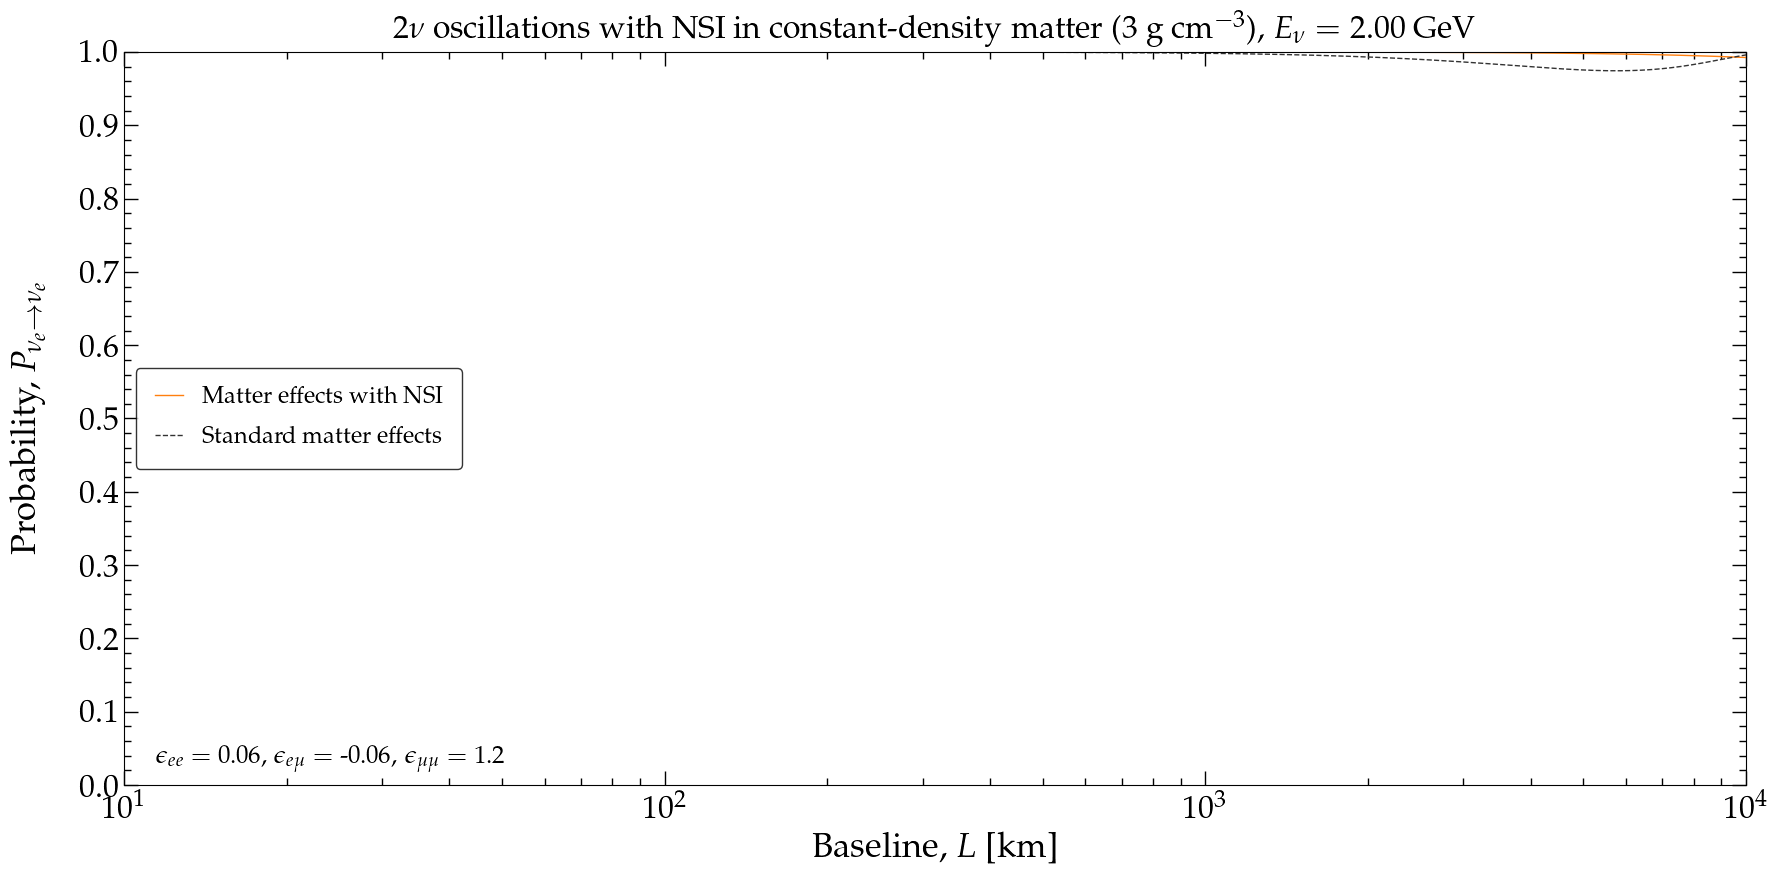

In [5]:
make_plot_prob_matt_std_vs_nsi_vs_baseline(gd.NUE, gd.NUE, distances, prob_matt_nsi_all, prob_matt_std_all, N=2,
                                           title=r'$2\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                           save_plot=False)

## 2.3 Probabilities vs. energy

In [6]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian without the 1/E prefactos
H_vac_en_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(s12, D21)

# Standard matter Hamiltonian
H_matt = hamiltonians.hamiltonian_2nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians.hamiltonian_2nu_nsi(VCC, eps_ee - eps_mm, eps_em)

# Total Hamiltonian, standard matter effects
def H_matt_std(energy, l):
    return (1/energy)*H_vac_en_indep + H_matt
prob_matt_std_all = np.array([oscprob.osc_prob(lambda l: H_matt_std(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# Total Hamiltonian, NSI matter effects
def H_matt_nsi(energy, l):
    return (1/energy)*H_vac_en_indep + H_matt + H_nsi
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda l: H_matt_nsi(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '$2\\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

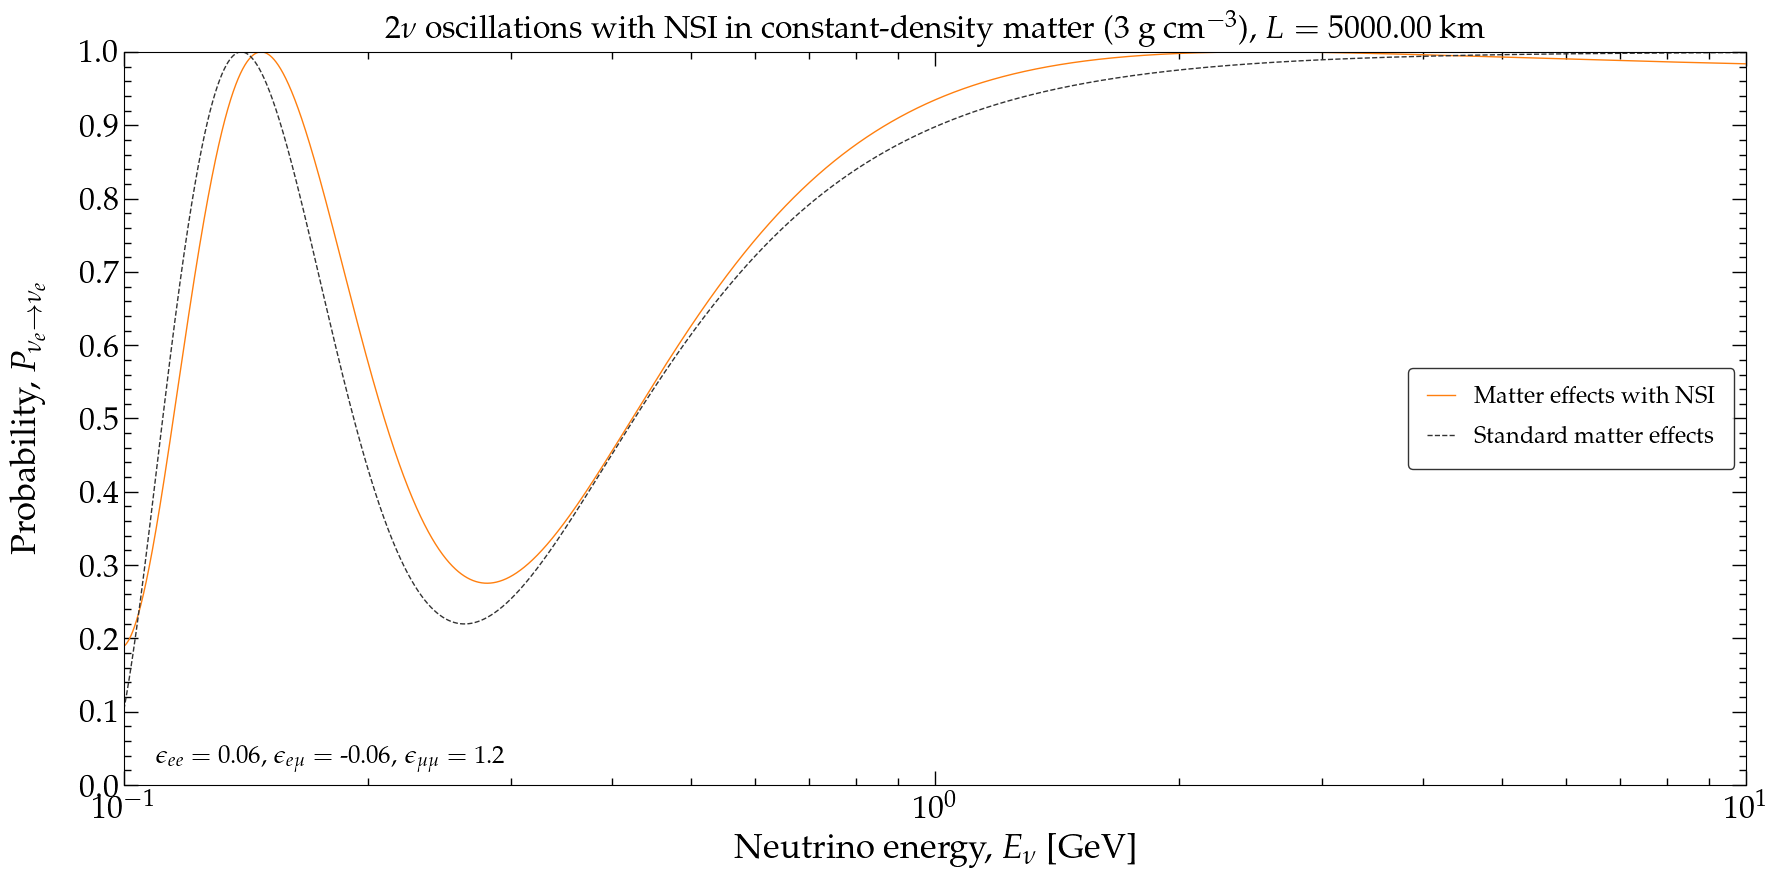

In [7]:
make_plot_prob_matt_std_vs_nsi_vs_energy(gd.NUE, gd.NUE, energies, prob_matt_nsi_all, prob_matt_std_all, N=2,
                                         title=r'$2\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                               r'$L = $~{:.2f}~km'.format(baseline),
                                         save_plot=False)

# 2. Probabilities with NSI in 3$\nu$: in matter with constant density

## 2.1 Mixing parameters and NSI parameters

In [8]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# NSI parameters (predefined exaples from globaldefs; can change them to anything else)
eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt = gd.EPS_3

## 2.2 Probabilities vs. distance

Generate probabilities

In [9]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 3nu case, osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian
H_vac = hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31)

# Standard matter Hamiltonian
H_matt = hamiltonians.hamiltonian_3nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians.hamiltonian_3nu_nsi(VCC, eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt)

# Probabilities
prob_matt_std_all = np.array([oscprob.osc_prob(lambda r: H_vac+H_matt, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda r: H_vac+H_matt+H_nsi, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])


Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '$3\\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

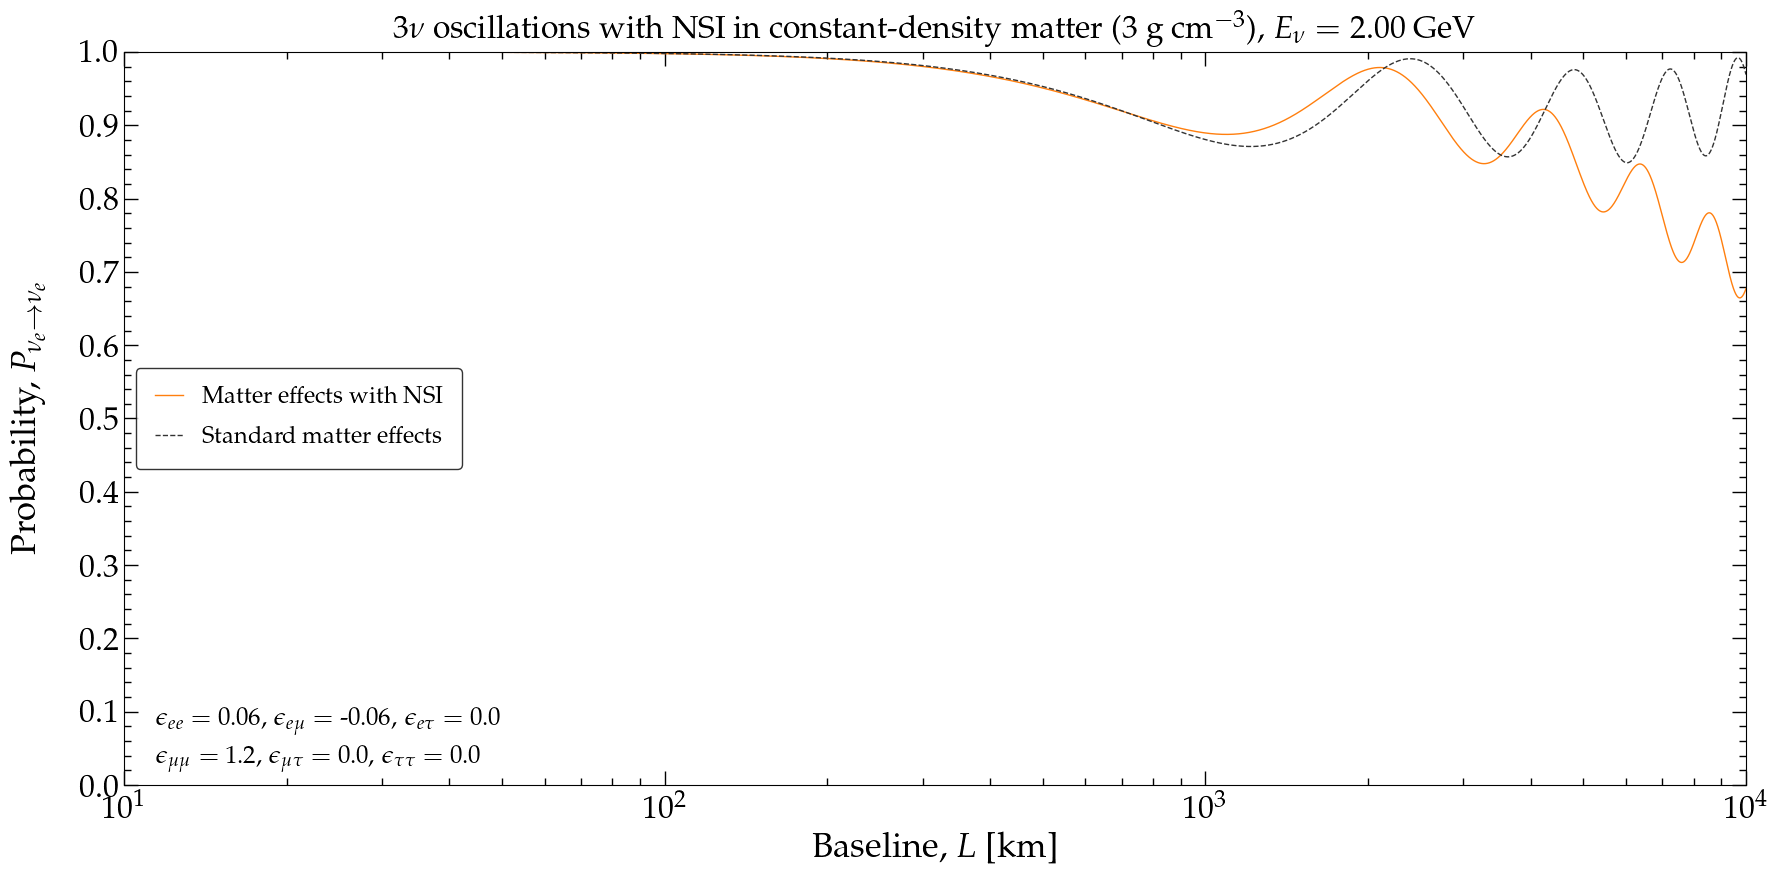

In [10]:
make_plot_prob_matt_std_vs_nsi_vs_baseline(gd.NUE, gd.NUE, distances, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                           title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                           save_plot=False)

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '$3\\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_\\mu \\to \\nu_\\tau}$'>)

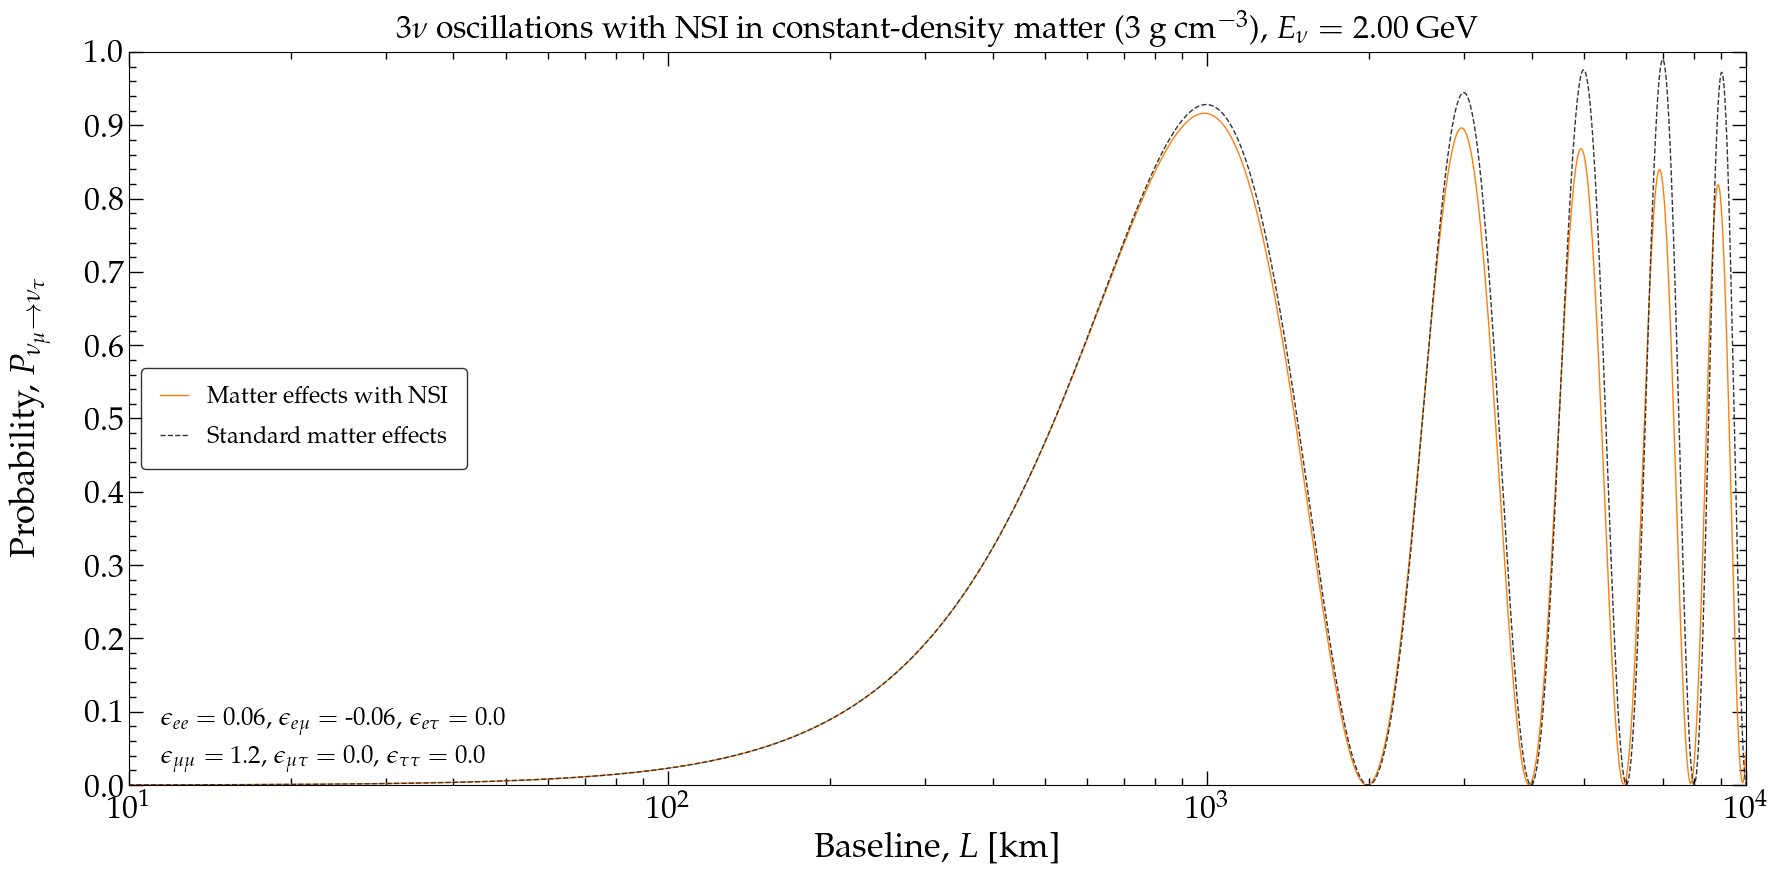

In [11]:
make_plot_prob_matt_std_vs_nsi_vs_baseline(gd.NUMU, gd.NUTAU, distances, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                           title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                           save_plot=False)

## 2.3 Probabilities vs. energy

Generate probabilities

In [12]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian without the 1/E prefactos
H_vac_en_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31)

# Standard matter Hamiltonian
H_matt = hamiltonians.hamiltonian_3nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians.hamiltonian_3nu_nsi(VCC, eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt)

# Total Hamiltonian, standard matter effects
def H_matt_std(energy, l):
    return (1/energy)*H_vac_en_indep + H_matt
prob_matt_std_all = np.array([oscprob.osc_prob(lambda l: H_matt_std(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# Total Hamiltonian, NSI matter effects
def H_matt_nsi(energy, l):
    return (1/energy)*H_vac_en_indep + H_matt + H_nsi
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda l: H_matt_nsi(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '$3\\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

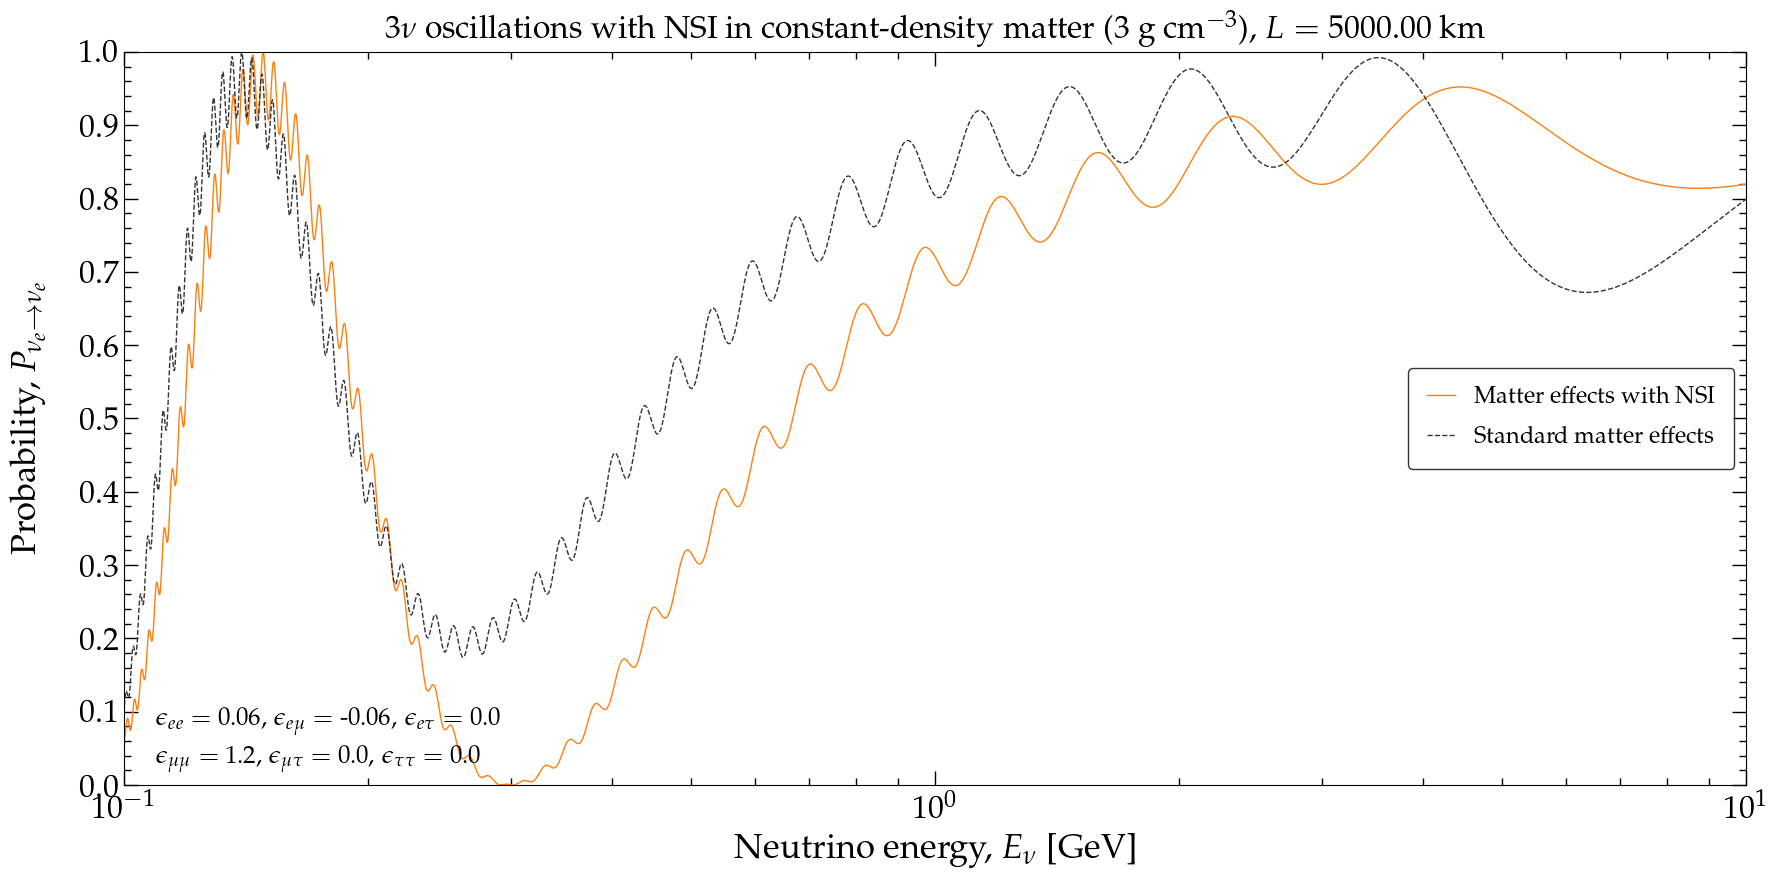

In [13]:
make_plot_prob_matt_std_vs_nsi_vs_energy(gd.NUE, gd.NUE, energies, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                         title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                               r'$L = $~{:.2f}~km'.format(baseline),
                                         save_plot=False)

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '$3\\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_\\mu \\to \\nu_\\tau}$'>)

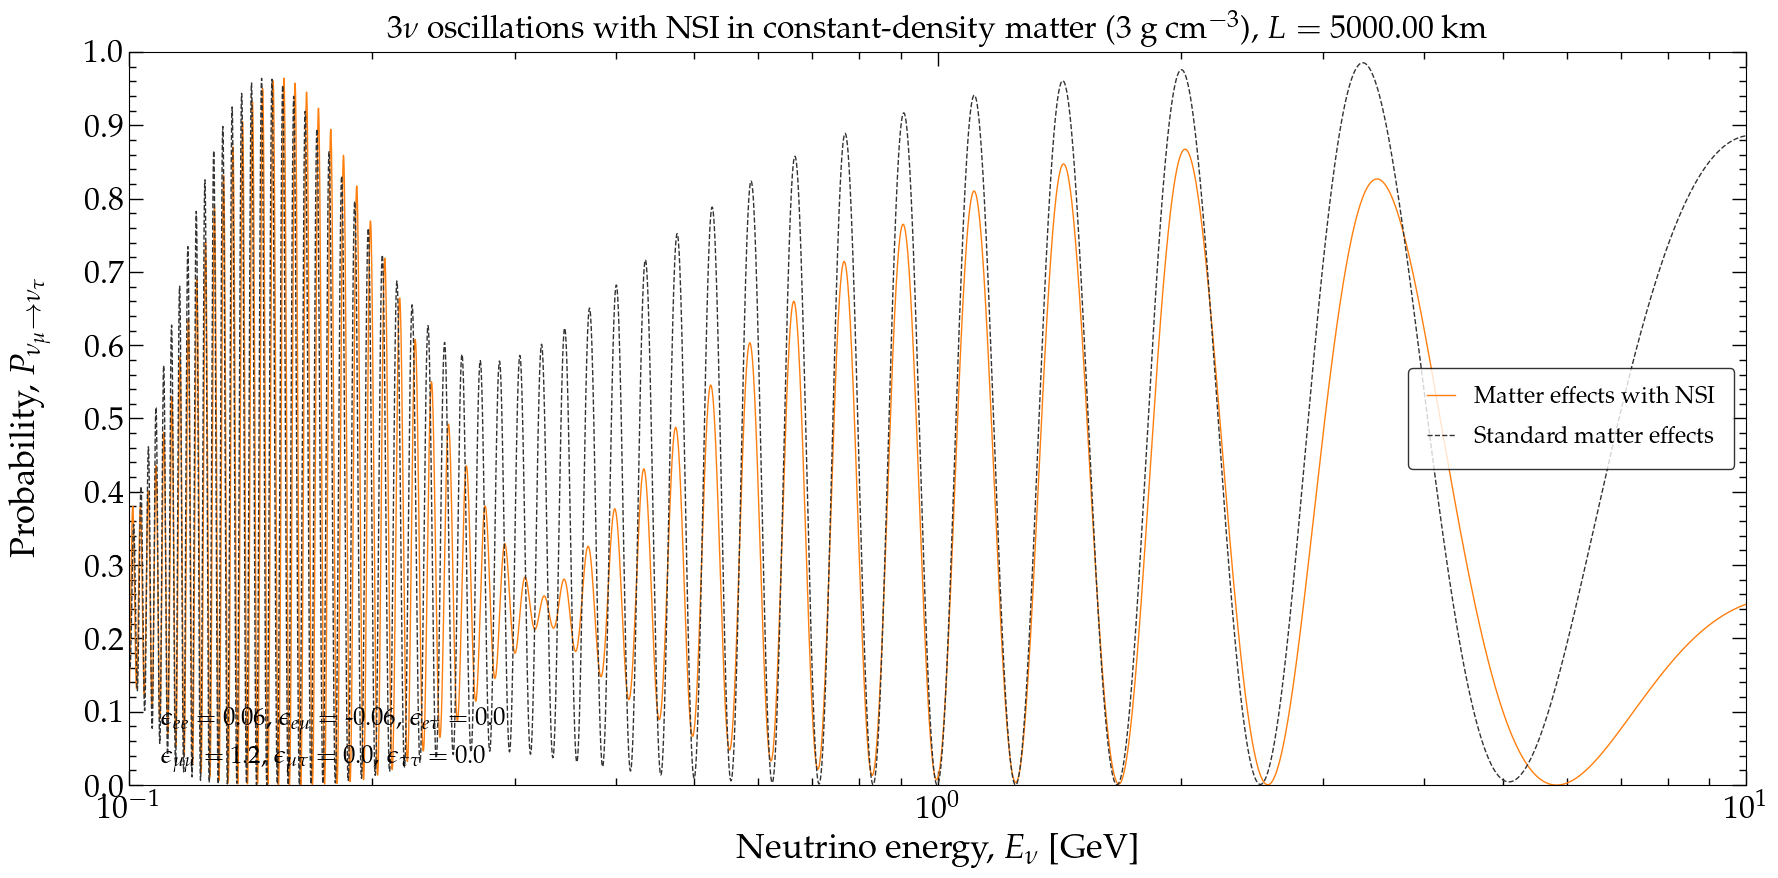

In [14]:
make_plot_prob_matt_std_vs_nsi_vs_energy(gd.NUMU, gd.NUTAU, energies, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                         title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                               r'$L = $~{:.2f}~km'.format(baseline),
                                         save_plot=False)